In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [ ]:
df.shape

(7043, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


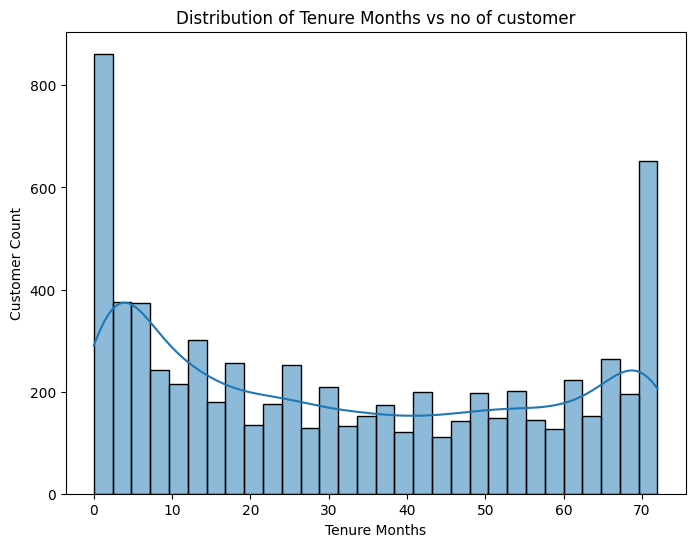

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df['Tenure Months'], bins = 30, kde = True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer Count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()


In [ ]:
df['Tenure Months'].max()
df['Tenure Months'].min()

0

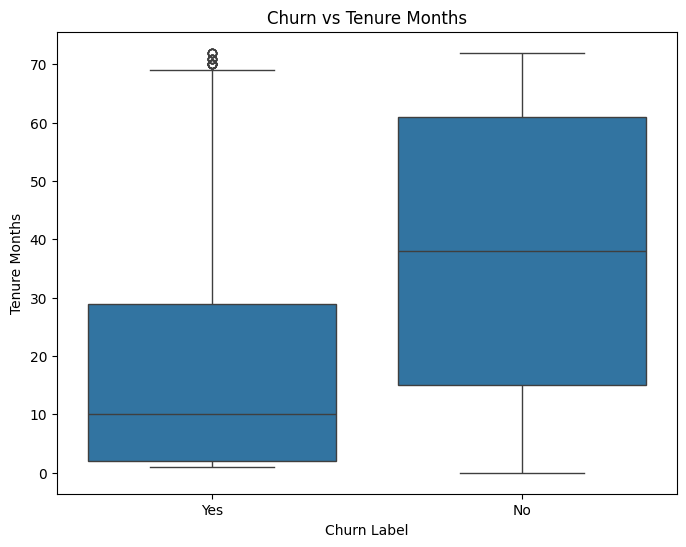

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn Label', y='Tenure Months', data=df)
plt.title('Churn vs Tenure Months')
plt.show()

In [ ]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

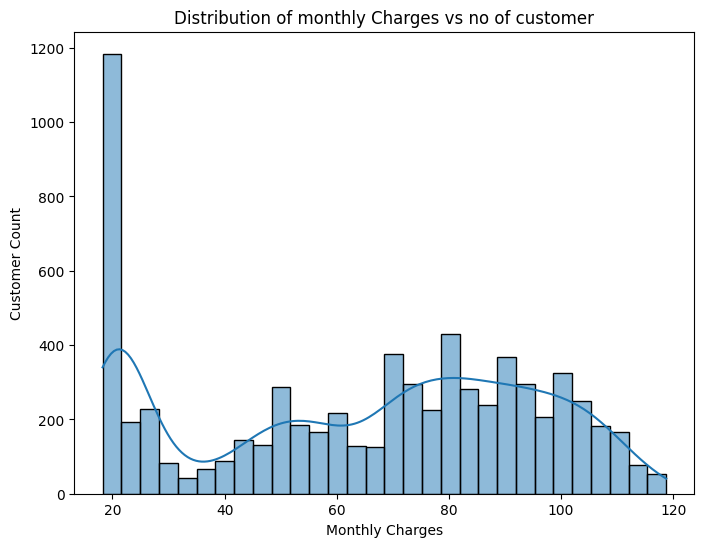

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df['Monthly Charges'], bins = 30, kde = True)
plt.xlabel('Monthly Charges')
plt.ylabel('Customer Count')
plt.title('Distribution of monthly Charges vs no of customer')
plt.show()

In [ ]:
df['Monthly Charges'].min()

18.25

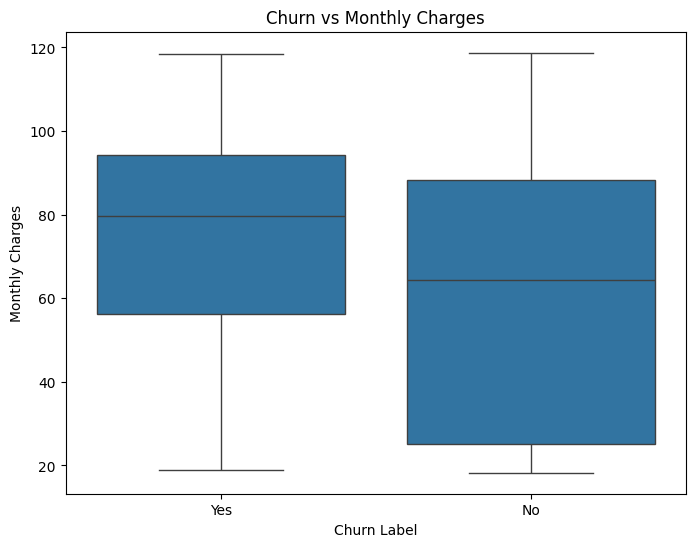

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df)
plt.title('Churn vs Monthly Charges')
plt.show()

In [ ]:
df[df['Churn Label'] == 'Yes'] ['Monthly Charges'].quantile([0.25, 0.50, 0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [ ]:
df[df['Churn Label'] == 'No'] ['Monthly Charges'].quantile([0.25, 0.50, 0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [ ]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [ ]:
df['Monthly Charges'].quantile([0.25, 0.50, 0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [ ]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

In [ ]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


Text(0.5, 1.0, 'Contract vs count')

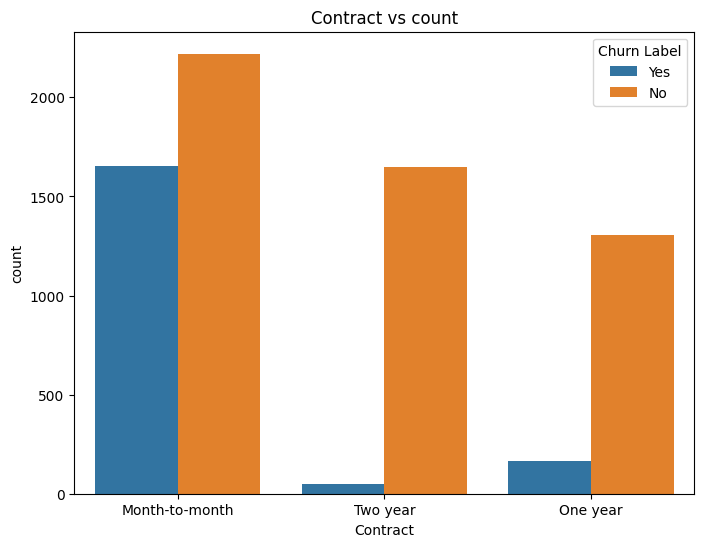

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x = 'Contract', hue = 'Churn Label', data=df)
plt.xlabel('Contract')
plt.ylabel('count')
plt.title('Contract vs count')

In [ ]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

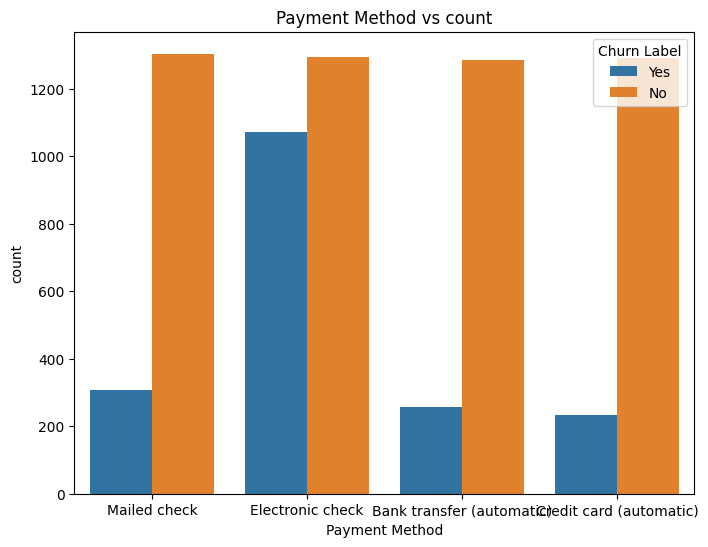

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x = 'Payment Method', hue = 'Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Payment Method vs count')
plt.show()

In [ ]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

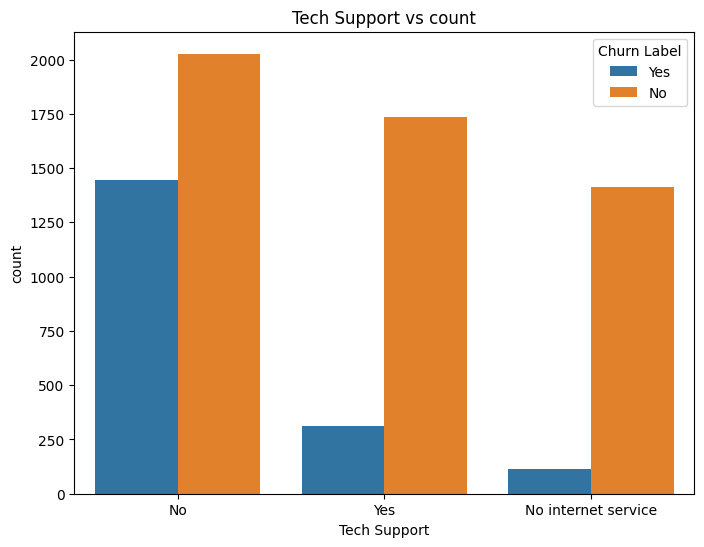

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x = 'Tech Support', hue = 'Churn Label', data=df)
plt.xlabel('Tech Support')
plt.ylabel('count')
plt.title('Tech Support vs count')
plt.show()

In [ ]:
avg_tenure = df.groupby('Churn Label')['Tenure Months'].mean()
print(avg_tenure)

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

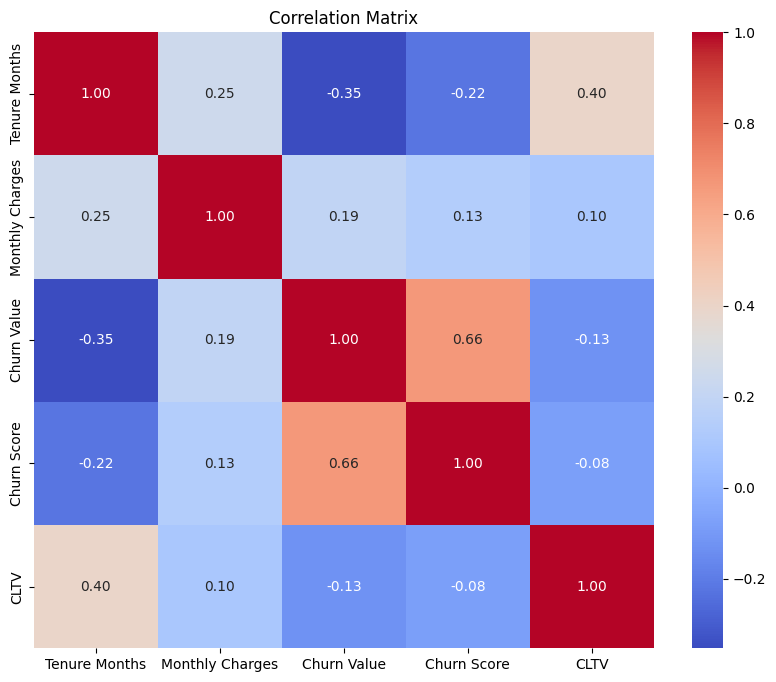

In [ ]:
numerical_cols = ['Tenure Months', 'Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [ ]:
contract_churn = pd.crosstab(df['Contract'], df['Churn Label'], normalize= 'index')
print(contract_churn)

Churn Label           No       Yes
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887305  0.112695
Two year        0.971681  0.028319


**Data Cleaning**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
display(df['Total Charges'])

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [ ]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

In [ ]:
df['Total Charges'].dtype

dtype('float64')

In [ ]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [ ]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [ ]:
df['Total Charges'] = df['Total Charges'].fillna(0)
df.shape

(7043, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [ ]:
columns_to_drop = [
    'CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long',
    'Latitude', 'Longitude', 'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason'
]

In [ ]:
df = df.drop(columns=columns_to_drop)

In [ ]:
df.shape

(7043, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [ ]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False


In [ ]:
df_encoded.shape

(7043, 31)

In [ ]:
df.shape

(7043, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [ ]:
df_encoded.shape

(7043, 31)

In [ ]:
df_encoded

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,False,False,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,0,True,False,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,0,False,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,0,False,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False


In [ ]:
x = df_encoded.drop('Churn Value', axis = 1)
y = df_encoded['Churn Value']

In [ ]:
x.shape
y.shape

(7043,)

In [ ]:
print(x)

      Tenure Months  Monthly Charges  Total Charges  Gender_Male  \
0                 2            53.85         108.15         True   
1                 2            70.70         151.65        False   
2                 8            99.65         820.50        False   
3                28           104.80        3046.05        False   
4                49           103.70        5036.30         True   
...             ...              ...            ...          ...   
7038             72            21.15        1419.40        False   
7039             24            84.80        1990.50         True   
7040             72           103.20        7362.90        False   
7041             11            29.60         346.45        False   
7042             66           105.65        6844.50         True   

      Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
0                  False        False           False               True   
1                  False       

In [ ]:
print(y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


**Machine Learning Implementation**

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [ ]:
x_train.shape

(5634, 30)

In [ ]:
x_test.shape

(1409, 30)

In [ ]:
y_train.shape

(5634,)

In [ ]:
y_test.shape

(1409,)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators = 100, random_state = 42)

In [ ]:
rf_model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = rf_model.predict(x_test)

In [ ]:
y_test

,Churn Value
185,1
2715,0
3825,0
1807,1
132,1
...,...
6366,0
315,1
2439,0
5002,0


In [ ]:
y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.7856635911994322


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

In [ ]:
print(cm)

[[902 107]
 [195 205]]


In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**Approach 1 - Handle class imbalance**

In [ ]:
rf_balanced = RandomForestClassifier(n_estimators = 100, random_state = 42, class_weight = 'balanced')
rf_balanced.fit(x_train, y_train)
y_pred_balanced = rf_balanced.predict(x_test)
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print(accuracy_balanced, cm_balanced)
print(classification_report(y_test, y_pred_balanced))

0.7920511000709723 [[907 102]
 [191 209]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**Approach 2- Hyperparameter tuning**

In [ ]:
rf_tuned = RandomForestClassifier(n_estimators = 200, random_state = 42, class_weight = 'balanced', max_depth = 10)
rf_tuned.fit(x_train, y_train)
y_pred_tuned = rf_tuned.predict(x_test)

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



**Approach 3 Feature importance analysis**

In [ ]:
import pandas as pd
feature_importance = pd.DataFrame({
    'features': x.columns,
    'importance': rf_tuned.feature_importances_
})
feature_importance = feature_importance.sort_values(by = 'importance', ascending = False)
print(feature_importance.tail(15))

                                  features  importance
16   Device Protection_No internet service    0.013370
3                              Gender_Male    0.012531
15                       Online Backup_Yes    0.012353
9                       Multiple Lines_Yes    0.011499
22    Streaming Movies_No internet service    0.011478
23                    Streaming Movies_Yes    0.010742
4                       Senior Citizen_Yes    0.010443
14       Online Backup_No internet service    0.010427
27  Payment Method_Credit card (automatic)    0.009442
21                        Streaming TV_Yes    0.008966
17                   Device Protection_Yes    0.008770
29             Payment Method_Mailed check    0.008364
20        Streaming TV_No internet service    0.007361
7                        Phone Service_Yes    0.003924
8          Multiple Lines_No phone service    0.003731


In [ ]:
x_selected = x.drop(['Phone Service_Yes', 'Multiple Lines_No phone service'], axis = 1)

In [ ]:
x_train_sel, x_test_sel, y_train_sel, y_test_sel = train_test_split(x_selected, y, test_size = 0.2, random_state = 42)

In [ ]:
rf_selected=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_selected.fit(x_train_sel,y_train_sel)
y_pred_selected=rf_selected.predict(x_test_sel)

print (classification_report(y_test_sel, y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



**Approach combinantion of trees and depth**

In [ ]:
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score

In [ ]:
n_estimators_list = [100, 200, 300, 400, 500]
max_depth_list = [5, 10, 15]
result = []

for n_trees in n_estimators_list:
    for depth in max_depth_list:
        rf = RandomForestClassifier(n_estimators=n_trees, max_depth=depth, random_state=42, class_weight= 'balanced')
        rf.fit(x_train, y_train)
        y_pred = rf.predict(x_test)
        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        result.append(
            {
                'Trees': n_trees,
                'Depth': depth,
                'Accuracy': accuracy,
                'Recall': recall,
                'Precision': precision,
                'F1': f1
            }
        )
    result_df = pd.DataFrame(result)
    result_df = result_df.sort_values(by=['Recall', 'Accuracy'], ascending=False)
    print(result_df)


   Trees  Depth  Accuracy  Recall  Precision        F1
0    100      5  0.745919  0.8200   0.534202  0.646943
1    100     10  0.775727  0.7525   0.581081  0.655773
2    100     15  0.802697  0.6300   0.659686  0.644501
   Trees  Depth  Accuracy  Recall  Precision        F1
0    100      5  0.745919  0.8200   0.534202  0.646943
3    200      5  0.742370  0.8100   0.530278  0.640950
1    100     10  0.775727  0.7525   0.581081  0.655773
4    200     10  0.782115  0.7450   0.592445  0.660022
5    200     15  0.804826  0.6350   0.663185  0.648787
2    100     15  0.802697  0.6300   0.659686  0.644501
   Trees  Depth  Accuracy  Recall  Precision        F1
0    100      5  0.745919  0.8200   0.534202  0.646943
6    300      5  0.743790  0.8200   0.531605  0.645034
3    200      5  0.742370  0.8100   0.530278  0.640950
1    100     10  0.775727  0.7525   0.581081  0.655773
7    300     10  0.782825  0.7475   0.593254  0.661504
4    200     10  0.782115  0.7450   0.592445  0.660022
8    300  

In [ ]:
from sklearn.model_selection import cross_val_score
final_rf = RandomForestClassifier(n_estimators=500, max_depth=10, random_state=42, class_weight='balanced')

In [ ]:
cv_accuracy = cross_val_score(final_rf, x, y, cv=5, scoring='accuracy')


In [ ]:
cv_accuracy

array([0.76721079, 0.79985806, 0.76224273, 0.78622159, 0.78053977])

In [ ]:
cv_accuracy.mean()

np.float64(0.7792145864249307)

In [ ]:
cv_recall = cross_val_score(final_rf, x, y, cv=5, scoring='recall')

In [ ]:
cv_recall

array([0.70588235, 0.77005348, 0.74064171, 0.7459893 , 0.70241287])

In [ ]:
cv_recall.mean()

np.float64(0.7329959427104988)

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [ ]:
y_prob = rf_tuned.predict_proba(x_test)

In [ ]:
churn_prob = y_prob[:, 1]
fpr, tpr, threshold = roc_curve(y_test, churn_prob)
auc_score = roc_auc_score(y_test, churn_prob)
print(auc_score)

0.8576176907829534


**Customer Segmentation**

In [ ]:
segmentation_data = pd.DataFrame({
    'Tenure Months': x_test['Tenure Months'],
    'Monthly Charges': x_test['Monthly Charges'],
    'Total Charges': x_test['Total Charges'],
    'churn_prob': churn_prob
})

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,churn_prob
185,15,85.90,1269.55,0.713808
2715,18,56.80,1074.65,0.334223
3825,2,20.00,40.90,0.230733
1807,6,84.20,519.15,0.818743
132,40,104.80,4131.95,0.472899
...,...,...,...,...
6366,66,104.90,6891.45,0.118528
315,19,86.00,1532.45,0.711495
2439,2,90.35,190.50,0.719700
5002,68,110.20,7467.50,0.065536


Implementation of K means

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-0.69631406  0.6691038  -0.45048988  1.13590877]
 [-0.57429095 -0.31419848 -0.53600108 -0.12966876]
 [-1.22508089 -1.55768728 -0.98955267 -0.47471724]
 [-1.0623834   0.61166002 -0.77972336  1.48577637]
 [ 0.32054522  1.30774342  0.80537089  0.33269319]]


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

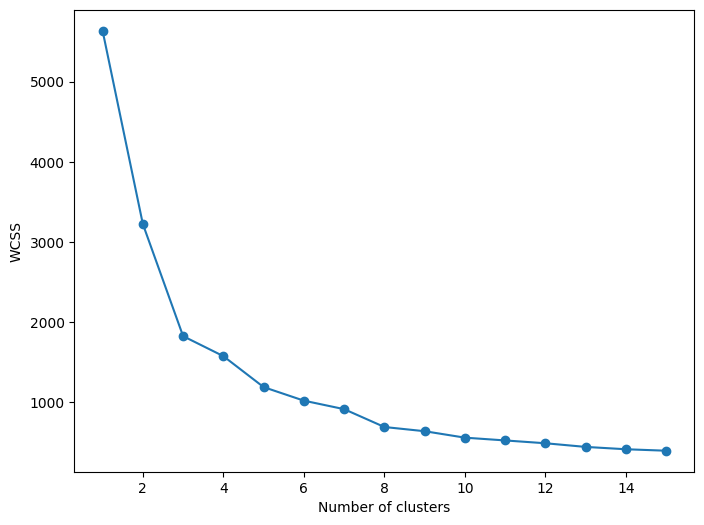

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 16):
    kmeans = KMeans(n_clusters=i,random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)
    plt.figure(figsize = (8,6))
plt.plot(range(1, 16), wcss, marker = 'o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,churn_prob
185,15,85.90,1269.55,0.713808
2715,18,56.80,1074.65,0.334223
3825,2,20.00,40.90,0.230733
1807,6,84.20,519.15,0.818743
132,40,104.80,4131.95,0.472899
...,...,...,...,...
6366,66,104.90,6891.45,0.118528
315,19,86.00,1532.45,0.711495
2439,2,90.35,190.50,0.719700
5002,68,110.20,7467.50,0.065536


In [ ]:
segmentation_data['Cluster'] = clusters

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,churn_prob,Cluster
185,15,85.90,1269.55,0.713808,0
2715,18,56.80,1074.65,0.334223,1
3825,2,20.00,40.90,0.230733,1
1807,6,84.20,519.15,0.818743,0
132,40,104.80,4131.95,0.472899,2
...,...,...,...,...,...
6366,66,104.90,6891.45,0.118528,2
315,19,86.00,1532.45,0.711495,0
2439,2,90.35,190.50,0.719700,0
5002,68,110.20,7467.50,0.065536,2


In [ ]:
cluster_summary = segmentation_data.groupby('Cluster').mean()

In [ ]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,churn_prob
Cluster,,,,
0,11.202578,73.761326,912.808471,0.683342
1,32.137387,33.427703,1085.845608,0.133557
2,59.014218,90.612322,5350.110782,0.225982


In [ ]:
cluster_names = {
    0: 'Budget Loyal Customers',
    1: 'High Risk New Customers',
    2: 'Loyal Premium Customers'
}

In [ ]:
segmentation_data['Cluster Segment'] = segmentation_data['Cluster'].map(cluster_names)

In [ ]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,churn_prob,Cluster,Cluster Segment
185,15,85.90,1269.55,0.713808,0,Budget Loyal Customers
2715,18,56.80,1074.65,0.334223,1,High Risk New Customers
3825,2,20.00,40.90,0.230733,1,High Risk New Customers
1807,6,84.20,519.15,0.818743,0,Budget Loyal Customers
132,40,104.80,4131.95,0.472899,2,Loyal Premium Customers
...,...,...,...,...,...,...
6366,66,104.90,6891.45,0.118528,2,Loyal Premium Customers
315,19,86.00,1532.45,0.711495,0,Budget Loyal Customers
2439,2,90.35,190.50,0.719700,0,Budget Loyal Customers
5002,68,110.20,7467.50,0.065536,2,Loyal Premium Customers


<Axes: xlabel='Monthly Charges', ylabel='churn_prob'>

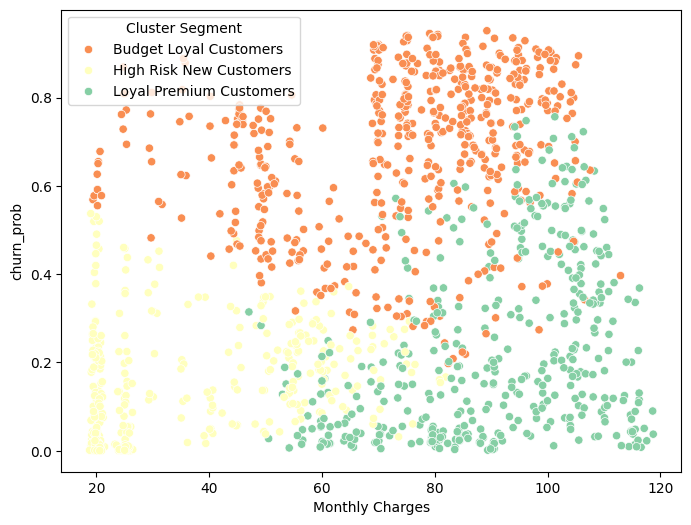

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Monthly Charges', y='churn_prob', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

<Axes: xlabel='Tenure Months', ylabel='churn_prob'>

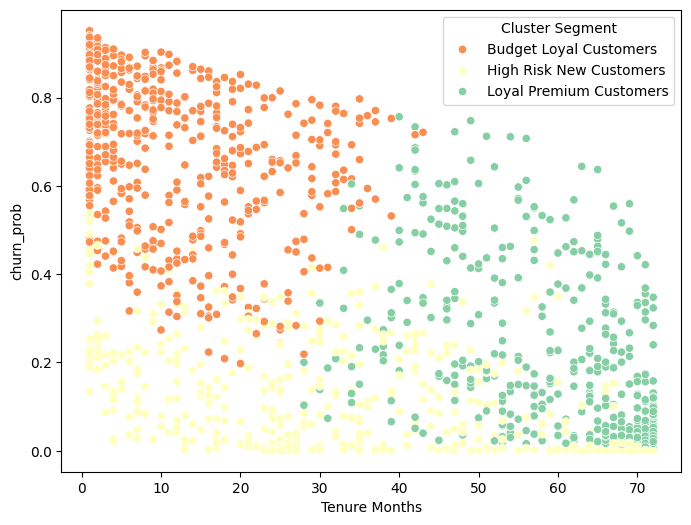

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Tenure Months', y='churn_prob', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

<Axes: xlabel='Total Charges', ylabel='churn_prob'>

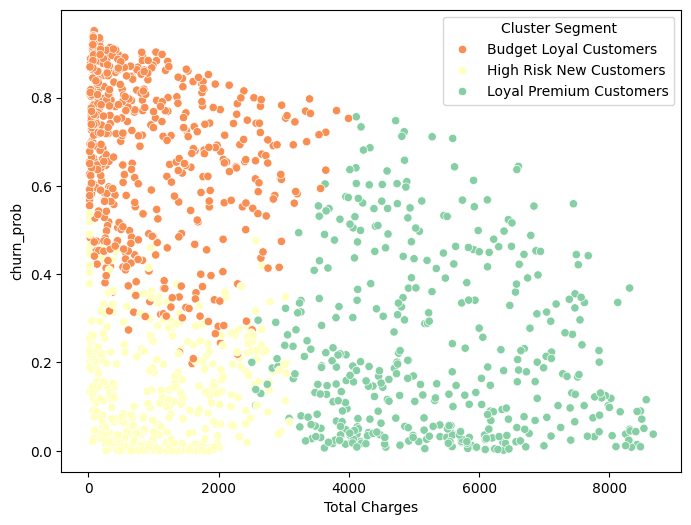

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Total Charges', y='churn_prob', hue='Cluster Segment', data=segmentation_data, palette='Spectral')